In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os
import statistics

years = range(2019,2025)

graphs = {}
returns = {}

base_modes = "../../data/02_clean"

for year in years:
    file_path = f"../../data/04_graphs/{year}/graph.gpickle"
    with open(file_path, "rb") as f:
        graphs[f"graph_{year}"] = pickle.load(f)
                
        returns[year] = pd.read_parquet(f"../../data/02_clean/returns_{year}.parquet")
        returns[year] = np.log(1 + returns[year])

In [105]:
import community as community_louvain

def calculate_hybrid_risk_metric(G, weights=None):
    # Default equal weights if not provided
    if weights is None:
        weights = {
            'degree': 1/4,
            'closeness': 1/4,
            'betweenness': 1/4,
            'eigenvector': 1/4
        }
    
    nodes = list(G.nodes)

    G = G.copy()
    for u, v, d in G.edges(data=True):
        d["distance"] = 1 / abs(d["weight"]) if d["weight"] != 0 else np.inf
    
    # 1. Calculate raw metrics
    
    # Degree
    degree_dict = dict(nx.degree(G, weight="weight"))
    
    # Clustering coefficient
    closeness_dict = nx.closeness_centrality(G, distance="distance")
    
    # Betweenness centrality
    betweenness_dict = nx.betweenness_centrality(G, weight='distance', normalized=True)
    
    # Eigenvector centrality
    eig_dict = nx.eigenvector_centrality(G, weight="weight")
    
    # 2. Normalize metrics (0=lowest risk, 1=highest risk)
    def normalize_dict(d, invert=False):
        vals = np.array(list(d.values()))
        min_val = vals.min()
        max_val = vals.max()
        if max_val - min_val == 0:
            # Avoid division by zero if all values equal
            return {k: 0.0 for k in d.keys()}
        norm = {k: (v - min_val) / (max_val - min_val) for k, v in d.items()}
        if invert:
            norm = {k: 1 - v for k, v in norm.items()}
        return norm
    
    norm_degree = normalize_dict(degree_dict, invert=False)
    norm_closeness = normalize_dict(closeness_dict, invert=False)
    norm_betweenness = normalize_dict(betweenness_dict, invert=False)
    norm_eig = normalize_dict(eig_dict, invert=False)
    
    # 3. Combine metrics with weights
    risk_scores = {}
    for node in nodes:
        score = (
            weights['degree'] * norm_degree[node] +
            weights['closeness'] * norm_closeness[node] +
            weights['betweenness'] * norm_betweenness[node] +
            weights['eigenvector'] * norm_eig[node] 
        )
        risk_scores[node] = score
    
    return risk_scores

In [106]:
risk_scores = {}
for year in years:
    print(f"Computing risk scores for {year}...")
    risk_scores[year] = calculate_hybrid_risk_metric(graphs[f"graph_{year}"])

df_long = pd.DataFrame([
    {"year": year, "stock": stock, "risk": score}
    for year, scores in risk_scores.items()
    for stock, score in scores.items()
])

df_wide = df_long.pivot(index="stock", columns="year", values="risk")

df_wide = df_wide.dropna()
print(f"Stocks present in all years: {len(df_wide)}")

Computing risk scores for 2019...
Computing risk scores for 2020...
Computing risk scores for 2021...
Computing risk scores for 2022...
Computing risk scores for 2023...
Computing risk scores for 2024...
Stocks present in all years: 401


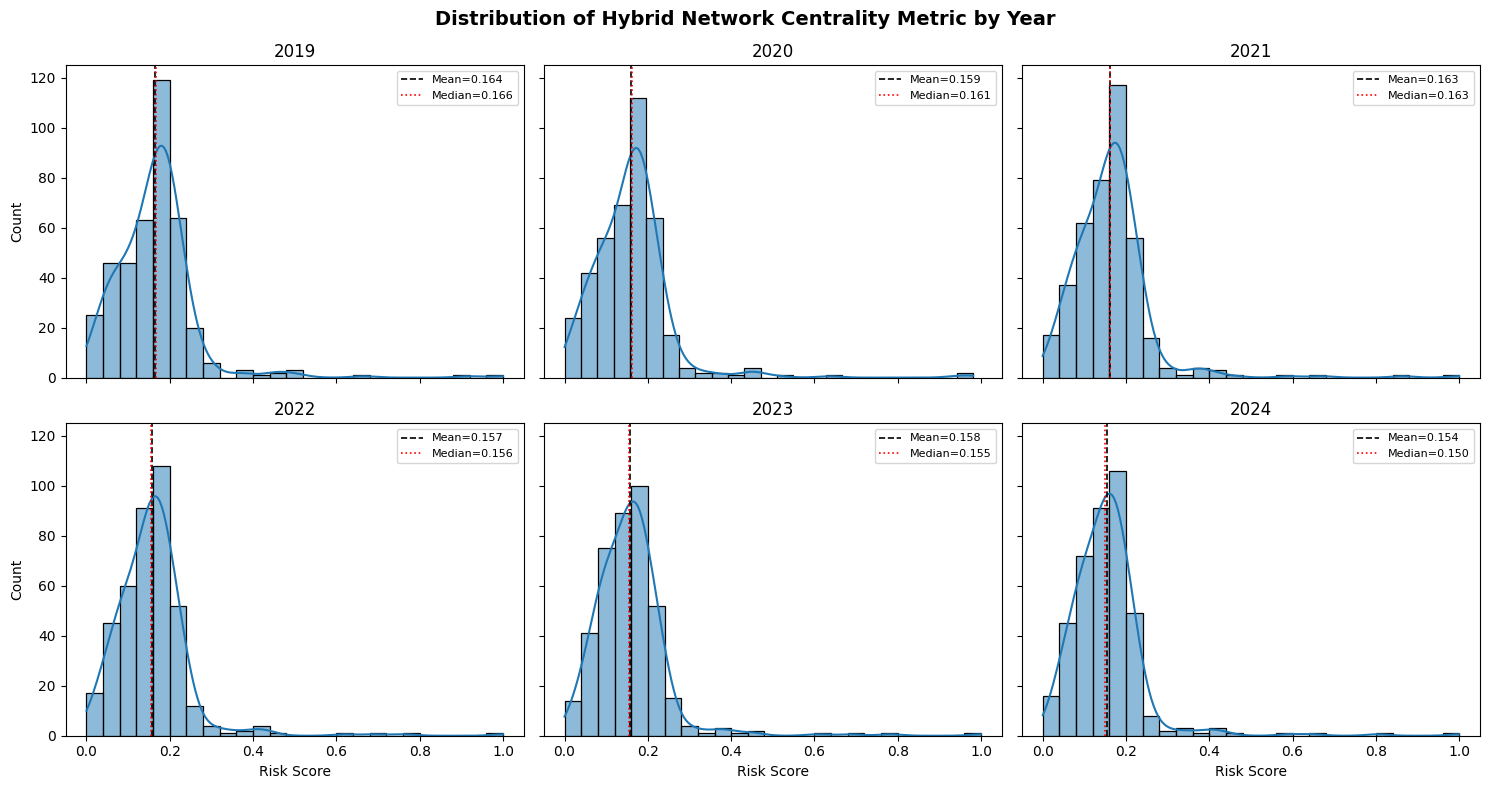

In [107]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
palette = sns.color_palette("tab10", 6)

for ax, year in zip(axes.flat, years):
    scores = list(risk_scores[year].values())
    sns.histplot(scores, kde=True, ax=ax, color=palette[0], bins=25)
    ax.axvline(np.mean(scores), color="black", linestyle="--", linewidth=1.2, label=f"Mean={np.mean(scores):.3f}")
    ax.axvline(np.median(scores), color="red",   linestyle=":",  linewidth=1.2, label=f"Median={np.median(scores):.3f}")
    ax.set_title(str(year), fontsize=12)
    ax.legend(fontsize=8)
    ax.set_xlabel("Risk Score")

fig.suptitle("Distribution of Hybrid Network Centrality Metric by Year", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [108]:
# ============================================================
# 2. SUMMARY STATISTICS TABLE
# ============================================================
summary_rows = []
for year in years:
    scores = np.array(list(risk_scores[year].values()))
    summary_rows.append({
        "Year":    year,
        "Mean":    scores.mean(),
        "Median":  np.median(scores),
        "Std":     scores.std(),
        "Skew":    pd.Series(scores).skew(),
        "Kurt":    pd.Series(scores).kurt(),
        "Min":     scores.min(),
        "Max":     scores.max(),
        "Q25":     np.percentile(scores, 25),
        "Q75":     np.percentile(scores, 75),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Year").round(4)
print(summary_df.to_string())
# print("\nLaTeX:\n", summary_df.to_latex())

        Mean  Median     Std    Skew     Kurt     Min     Max     Q25     Q75
Year                                                                         
2019  0.1636  0.1662  0.0985  3.2887  22.6675  0.0001  1.0000  0.1090  0.2004
2020  0.1592  0.1614  0.0965  3.4957  24.9125  0.0002  0.9809  0.1025  0.1942
2021  0.1630  0.1628  0.0942  3.5365  24.9408  0.0001  1.0000  0.1098  0.1962
2022  0.1574  0.1556  0.0928  3.5199  24.5441  0.0001  1.0000  0.1041  0.1919
2023  0.1581  0.1552  0.0917  3.6866  26.0255  0.0000  1.0000  0.1057  0.1924
2024  0.1539  0.1500  0.0905  3.8573  28.0429  0.0004  1.0000  0.1029  0.1872


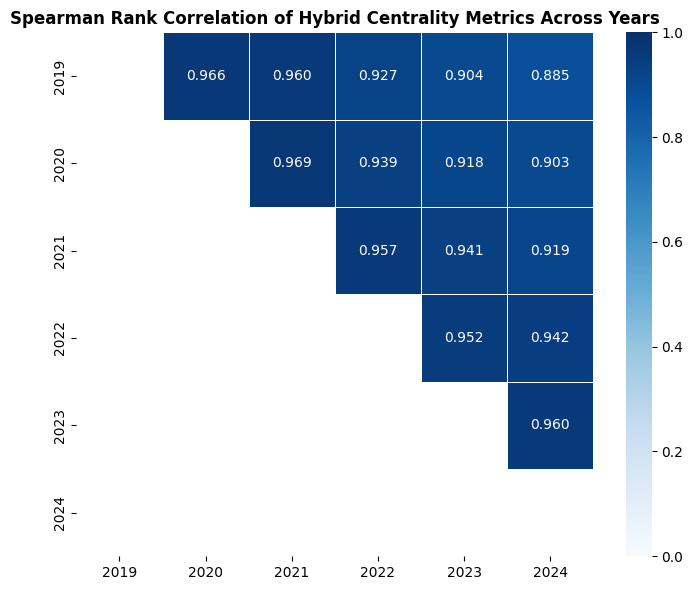

In [109]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = df_wide.corr(method="spearman")
corr.index   = [str(y) for y in corr.index]
corr.columns = [str(y) for y in corr.columns]

mask = np.tril(np.ones_like(corr, dtype=bool))  # mask lower triangle + diagonal

sns.heatmap(corr, annot=True, fmt=".3f", cmap="Blues",
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            mask=mask)
ax.set_title("Spearman Rank Correlation of Hybrid Centrality Metrics Across Years", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [110]:
centralities = ["central", "peripheral"]
portfolios = {}

for year in years:
    for centrality in centralities:
        cols = pd.read_csv(f"../../data/06_portfolios/{centrality}_{year}.csv", index_col="Date").columns.tolist()
        portfolios[f"{centrality}_{year}"] = pd.read_parquet(f"../../data/02_clean/returns_{year-9}_{year}.parquet")[cols]

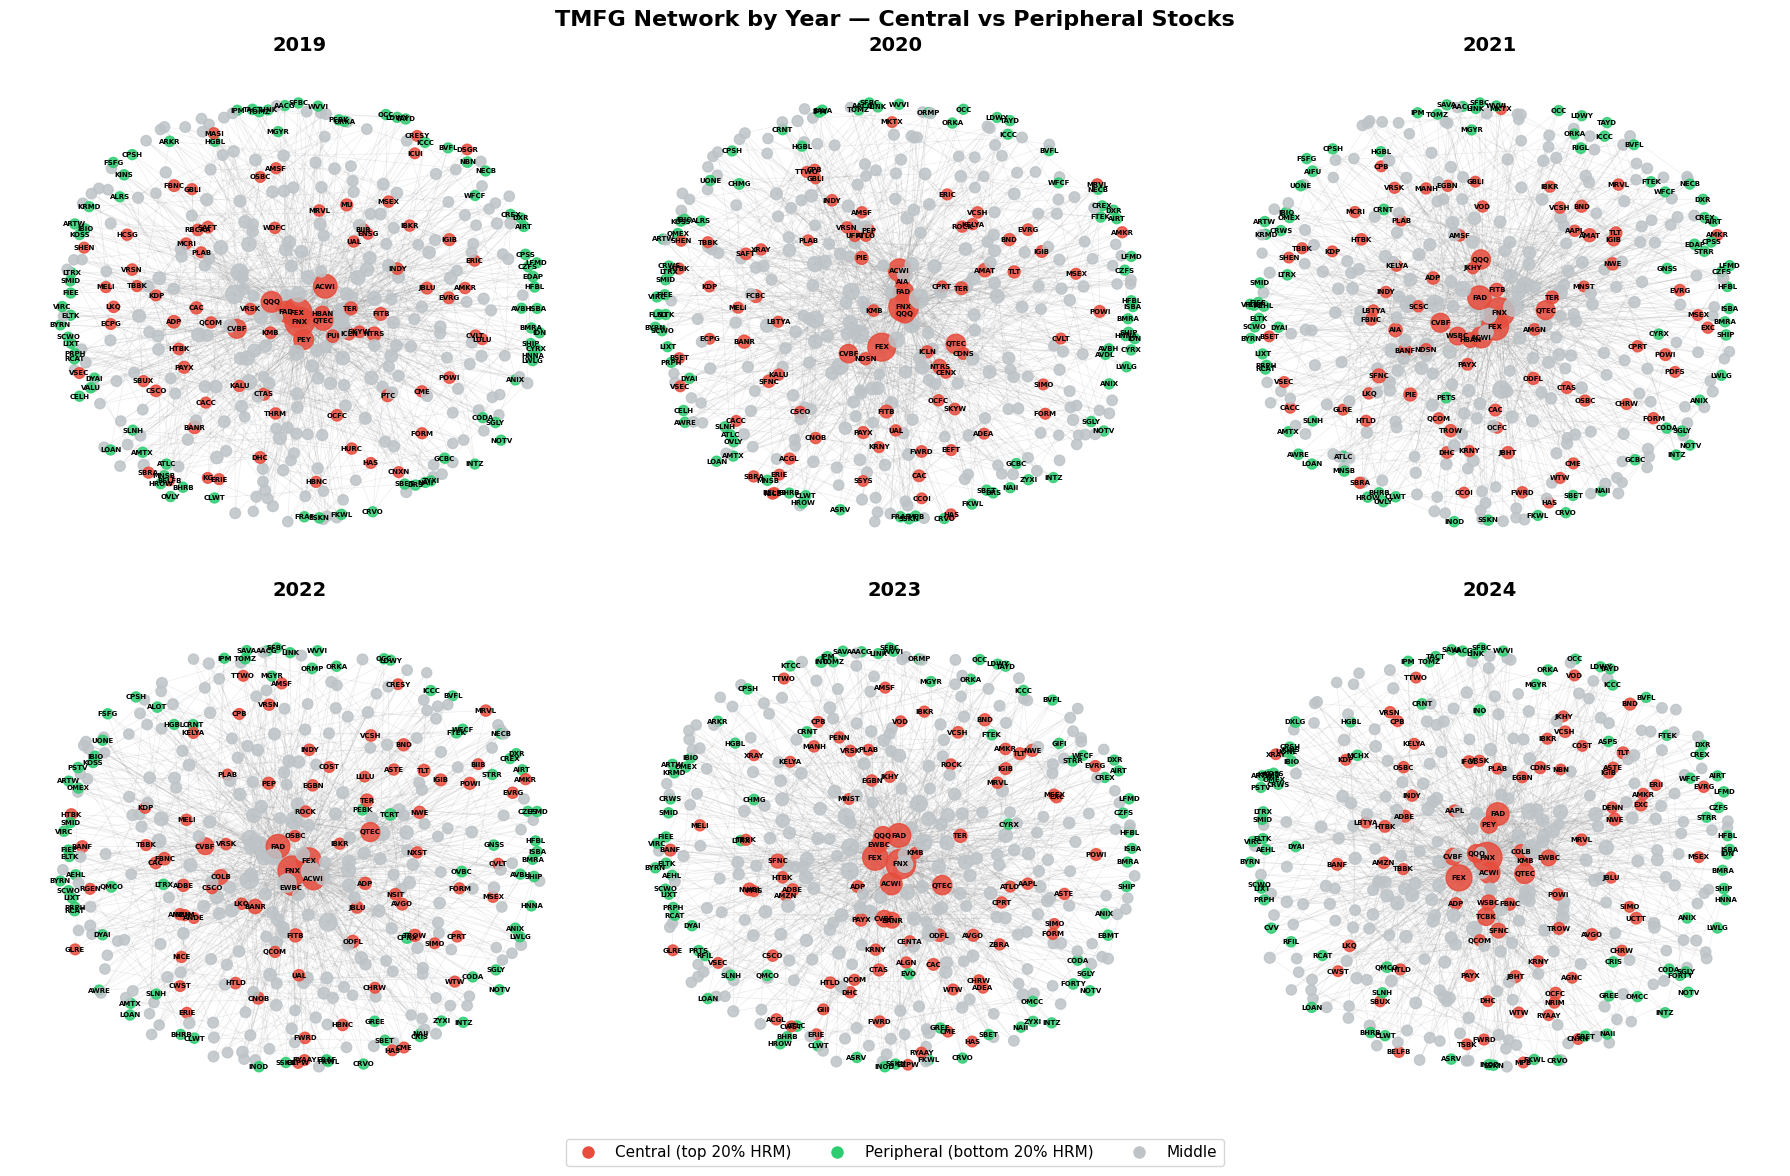

In [111]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, year in zip(axes.flat, years):
    G = graphs[f"graph_{year}"]
    
    # Get portfolio membership for this year
    central_tickers    = set(portfolios[f"central_{year}"].columns)
    peripheral_tickers = set(portfolios[f"peripheral_{year}"].columns)
    
    # Assign colors
    node_colors = []
    for node in G.nodes():
        if node in central_tickers:
            node_colors.append("#E74C3C")       # red  = high risk / central
        elif node in peripheral_tickers:
            node_colors.append("#2ECC71")       # green = low risk / peripheral
        else:
            node_colors.append("#BDC3C7")       # grey = middle

    node_sizes = []
    degree = dict(G.degree(weight="weight"))
    max_deg = max(degree.values())
    for node in G.nodes():
        node_sizes.append(50 + 400 * (degree[node] / max_deg))  # scale by weighted degree

    # Layout — spring layout seeded for reproducibility
    pos = nx.spring_layout(G, seed=42, k=0.4)

    # Draw edges (light grey, thin)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, width=0.5, edge_color="grey")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors,
                           node_size=node_sizes,
                           alpha=0.85)

    # Labels only for central/peripheral nodes to avoid clutter
    labels = {n: n for n in G.nodes() if n in central_tickers | peripheral_tickers}
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=5, font_weight="bold")

    ax.set_title(str(year), fontsize=14, fontweight="bold")
    ax.axis("off")

# Shared legend
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#E74C3C", markersize=10, label="Central (top 20% HRM)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2ECC71", markersize=10, label="Peripheral (bottom 20% HRM)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#BDC3C7", markersize=10, label="Middle"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, 0.01), frameon=True)

fig.suptitle("TMFG Network by Year — Central vs Peripheral Stocks", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

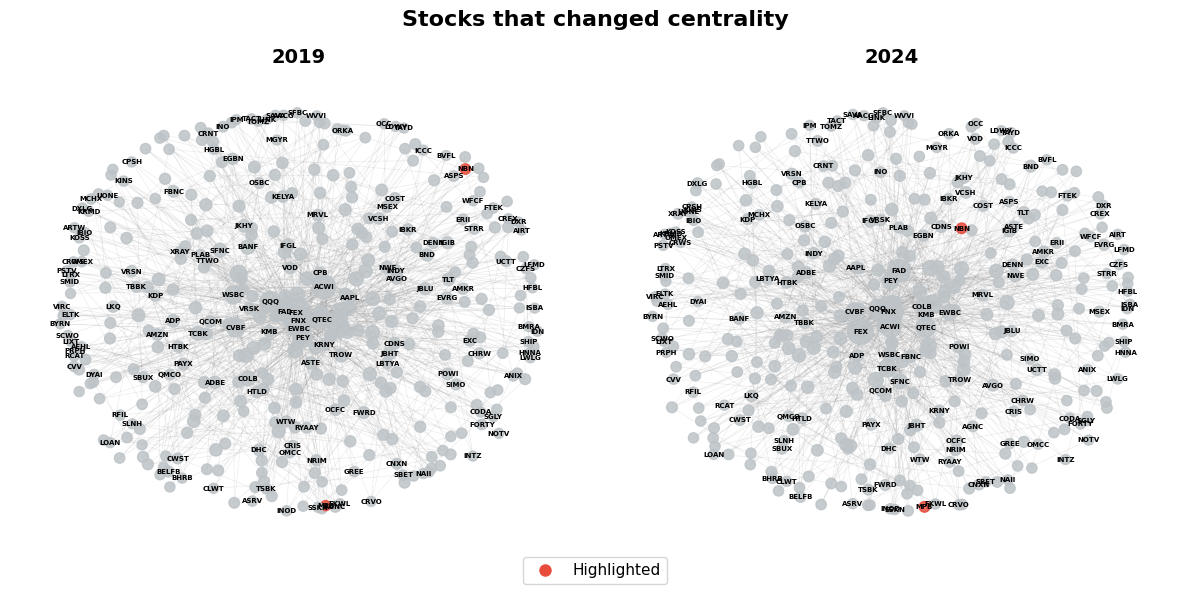

In [87]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(12,6))

for ax, year in zip(axes.flat, [2019, 2024]):
    G = graphs[f"graph_{year}"]
    
    # Get portfolio membership for this year
    tickers = ["MPB", "NBN"]
    
    # Assign colors
    node_colors = []
    for node in G.nodes():
        if node in tickers:
            node_colors.append("#E74C3C")       # red  = high risk / central
        else:
            node_colors.append("#BDC3C7")       # grey = middle

    node_sizes = []
    degree = dict(G.degree(weight="weight"))
    max_deg = max(degree.values())
    for node in G.nodes():
        node_sizes.append(50 + 400 * (degree[node] / max_deg))  # scale by weighted degree

    # Layout — spring layout seeded for reproducibility
    pos = nx.spring_layout(G, seed=42, k=0.4)

    # Draw edges (light grey, thin)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, width=0.5, edge_color="grey")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors,
                           node_size=node_sizes,
                           alpha=0.85)

    # Labels only for central/peripheral nodes to avoid clutter
    labels = {n: n for n in G.nodes() if n in central_tickers | peripheral_tickers}
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=5, font_weight="bold")

    ax.set_title(str(year), fontsize=14, fontweight="bold")
    ax.axis("off")

# Shared legend
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#E74C3C", markersize=10, label="Highlighted"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, 0.01), frameon=True)

fig.suptitle("Stocks that changed centrality", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [102]:
year = 2019
G = graphs[f"graph_{year}"]

for u, v, d in G.edges(data=True):
    d["distance"] = 1 / abs(d["weight"]) if d["weight"] != 0 else np.inf

# --- Degree (weighted strength) ---
degree = dict(nx.degree(G, weight="weight"))

# --- Weighted clustering coefficient ---
clustering = nx.clustering(G, weight="weight")

# --- Weighted betweenness centrality ---
betweenness = nx.betweenness_centrality(G, weight="distance", normalized=True)

# --- Average absolute edge weight per node ---
eig = nx.eigenvector_centrality(G, weight="weight")

# --- Combine everything into a DataFrame ---
metrics = pd.DataFrame({
    "stock": list(G.nodes()),
    "degree": [degree[n] for n in G.nodes()],
    "clustering": [clustering[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()],
    "eigenvector": [eig[n] for n in G.nodes()]
})

metrics

,stock,degree,clustering,betweenness,eigenvector
0,AACG,0.224712,0.152140,0.000000,0.002764
1,AAPL,2.083821,0.234816,0.002682,0.029616
2,ACGL,2.375006,0.274245,0.000013,0.046453
3,ACIC,0.752522,0.214543,0.000000,0.024583
4,ACIW,2.481337,0.161203,0.005013,0.053429
...,...,...,...,...,...
396,XOMA,0.715310,0.295453,0.000000,0.006716
397,XRAY,1.744423,0.274894,0.000000,0.030657
398,ZBRA,2.093141,0.182321,0.000013,0.046111
399,ZUMZ,1.276761,0.302850,0.000000,0.019407
